# 02 - Análisis exploratorio de los datos

## Objetivos

1. Analizar el comportamiento de los activos.
2. Identificar los más rentables y los más volátiles.
3. Estudiar las correlaciones.
4. Obtener información que justifique la construcción del portafolio.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [19]:
from pathlib import Path

# Ruta donde se guardarán las figuras
FIGURES_DIR = Path("../reports/figures")

# Crear la carpeta si no existe
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
returns = pd.read_csv(
    "../data/processed/daily_returns.csv",
    index_col=0,
    parse_dates=True
)

returns.head()

,AAPL,CAT,JNJ,JPM,KO,MSFT,NVDA,SPY,V,WMT,XOM
Date,,,,,,,,,,,
2018-01-03,-0.000174,0.001528,0.009553,0.001019,-0.002196,0.004654,0.065814,0.006325,0.009955,0.008723,0.019640
2018-01-04,0.004645,0.013733,-0.000071,0.014326,0.014085,0.008802,0.005271,0.004214,0.003718,0.000905,0.001384
2018-01-05,0.011385,0.015805,0.008253,-0.006419,-0.000217,0.012398,0.008475,0.006664,0.023949,0.005927,-0.000806
2018-01-08,-0.003714,0.025130,0.001270,0.001477,-0.001519,0.001020,0.030641,0.001829,0.004038,0.014781,0.004496
2018-01-09,-0.000115,0.002409,0.015857,0.005069,0.005000,-0.000680,-0.000270,0.002264,-0.001927,-0.012007,-0.004246


In [3]:
returns.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1760 entries, 2018-01-03 to 2024-12-31
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    1760 non-null   float64
 1   CAT     1760 non-null   float64
 2   JNJ     1760 non-null   float64
 3   JPM     1760 non-null   float64
 4   KO      1760 non-null   float64
 5   MSFT    1760 non-null   float64
 6   NVDA    1760 non-null   float64
 7   SPY     1760 non-null   float64
 8   V       1760 non-null   float64
 9   WMT     1760 non-null   float64
 10  XOM     1760 non-null   float64
dtypes: float64(11)
memory usage: 165.0 KB


## Estadísticas descriptivas de los rendimientos diarios

Las estadísticas descriptivas permiten conocer el comportamiento histórico de los rendimientos diarios de cada activo seleccionado.

Se observa que:

- **NVIDIA (NVDA)** presenta el mayor rendimiento promedio diario (0.24%), lo que explica por qué posteriormente muestra el mayor rendimiento anual esperado. Sin embargo, también registra la mayor volatilidad, reflejando un mayor nivel de riesgo.

- **Apple (AAPL)** y **Microsoft (MSFT)** muestran rendimientos promedio elevados (0.12% y 0.11% diarios respectivamente), combinando crecimiento con una volatilidad inferior a la de NVIDIA.

- **Johnson & Johnson (JNJ)** y **Coca-Cola (KO)** presentan los menores rendimientos diarios promedio, aunque también exhiben una menor dispersión de los datos, características propias de empresas defensivas.

- Los valores mínimos y máximos evidencian que todos los activos experimentaron movimientos extremos durante el período analizado, especialmente durante episodios de alta incertidumbre en el mercado.

En general, existe un claro compromiso entre rentabilidad esperada y riesgo: los activos con mayores rendimientos promedio también presentan una mayor volatilidad.

In [4]:
returns.describe().T

,count,mean,std,min,25%,50%,75%,max
AAPL,1760.0,0.001220,0.019242,-0.128647,-0.008034,0.001276,0.011506,0.119808
CAT,1760.0,0.000768,0.020014,-0.142822,-0.009651,0.000731,0.011693,0.103321
JNJ,1760.0,0.000207,0.012325,-0.100379,-0.005477,0.000403,0.006078,0.079977
JPM,1760.0,0.000739,0.018640,-0.149649,-0.007769,0.000669,0.009117,0.180125
KO,1760.0,0.000379,0.012315,-0.096725,-0.005156,0.000694,0.006120,0.064795
MSFT,1760.0,0.001113,0.018197,-0.147391,-0.007511,0.001281,0.010731,0.142169
NVDA,1760.0,0.002405,0.032465,-0.187559,-0.015233,0.002863,0.019927,0.243696
SPY,1760.0,0.000583,0.012259,-0.109423,-0.004396,0.000787,0.006688,0.090603
V,1760.0,0.000742,0.016586,-0.135472,-0.007132,0.001452,0.008642,0.138427
WMT,1760.0,0.000736,0.013734,-0.113758,-0.005576,0.000833,0.007240,0.117085


## Rendimiento anual esperado

El rendimiento anual esperado se obtuvo anualizando el rendimiento promedio diario mediante la multiplicación por 252 días bursátiles.

Los resultados muestran que:

- **NVIDIA (NVDA)** posee el mayor rendimiento esperado, superando ampliamente al resto de activos.
- **Apple (AAPL)** y **Microsoft (MSFT)** ocupan el segundo y tercer lugar, consolidándose como empresas con un fuerte crecimiento durante el período analizado.
- **SPY**, utilizado como referencia del mercado estadounidense, presenta un rendimiento esperado inferior al de varias acciones individuales.
- Empresas más maduras como **JNJ**, **KO** y **XOM** muestran rendimientos esperados considerablemente menores.

Estos resultados reflejan que las empresas tecnológicas han generado un crecimiento superior durante los últimos años, aunque este comportamiento deberá analizarse junto con su nivel de riesgo.

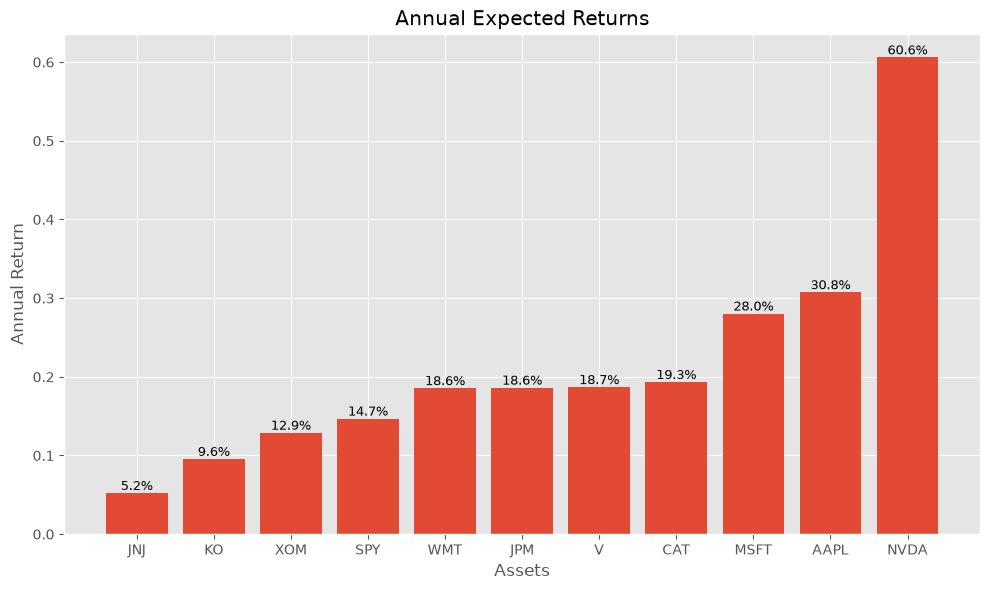

In [20]:
# ======================================
# Rendimientos anualizados
# ======================================

annual_returns = returns.mean() * 252

fig, ax = plt.subplots(figsize=(10,6))

bars = ax.bar(
    annual_returns.sort_values().index,
    annual_returns.sort_values().values
)

ax.set_title("Annual Expected Returns")
ax.set_xlabel("Assets")
ax.set_ylabel("Annual Return")

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1%}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "annual_returns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Volatilidad anual

La volatilidad anual representa el nivel de riesgo asociado a cada activo y se calculó anualizando la desviación estándar de los rendimientos diarios.

Los resultados indican que:

- **NVIDIA (NVDA)** es el activo más riesgoso del portafolio, con una volatilidad significativamente superior al resto.
- **Caterpillar (CAT)**, **Exxon Mobil (XOM)**, **Apple (AAPL)** y **JPMorgan (JPM)** presentan niveles intermedios de volatilidad.
- **SPY**, **KO** y **JNJ** exhiben las menores volatilidades, reflejando un comportamiento más estable.

En términos financieros, una mayor volatilidad implica una mayor incertidumbre sobre los rendimientos futuros. Por ello, este indicador será fundamental durante la optimización del portafolio mediante el modelo de Markowitz.

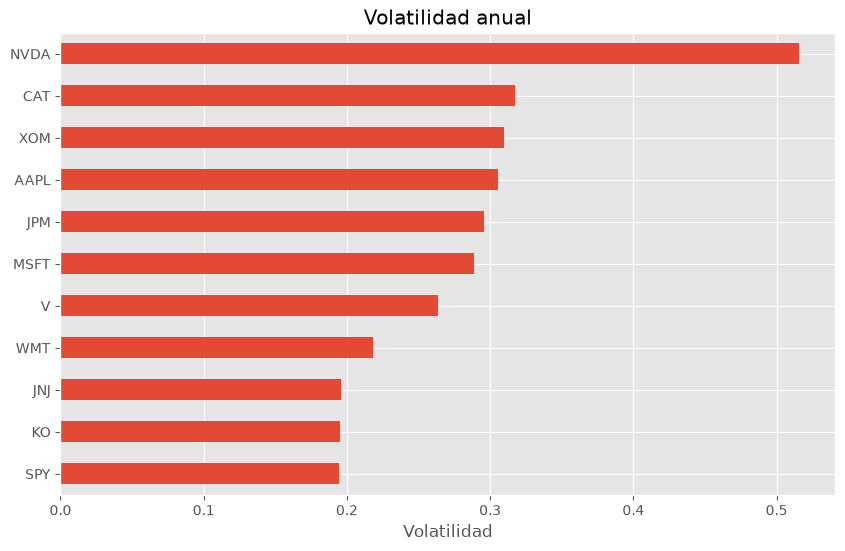

In [17]:
annual_volatility = returns.std() * np.sqrt(252)
annual_volatility.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Volatilidad anual")
plt.xlabel("Volatilidad")
plt.show()

## Matriz de correlación

La matriz de correlación permite medir el grado en que los activos se mueven conjuntamente.

Se observan varios patrones importantes:

- **SPY** presenta una alta correlación con **Microsoft (0.82)**, **Apple (0.78)** y **Visa (0.78)**, lo que indica que estos activos siguen de cerca el comportamiento general del mercado.

- **Apple** y **Microsoft** muestran una correlación elevada (0.73), reflejando la fuerte relación existente entre grandes compañías tecnológicas.

- **NVIDIA** mantiene correlaciones moderadas con la mayoría de los activos, lo que sugiere un comportamiento parcialmente independiente respecto a otros sectores.

- Empresas de consumo defensivo como **Coca-Cola** y **Johnson & Johnson** presentan correlaciones relativamente menores frente a las empresas tecnológicas.

Desde la perspectiva de diversificación, los activos con correlaciones más bajas ofrecen un mayor potencial para reducir el riesgo total del portafolio al combinarse con otros activos.

In [15]:
correlation = returns.corr()


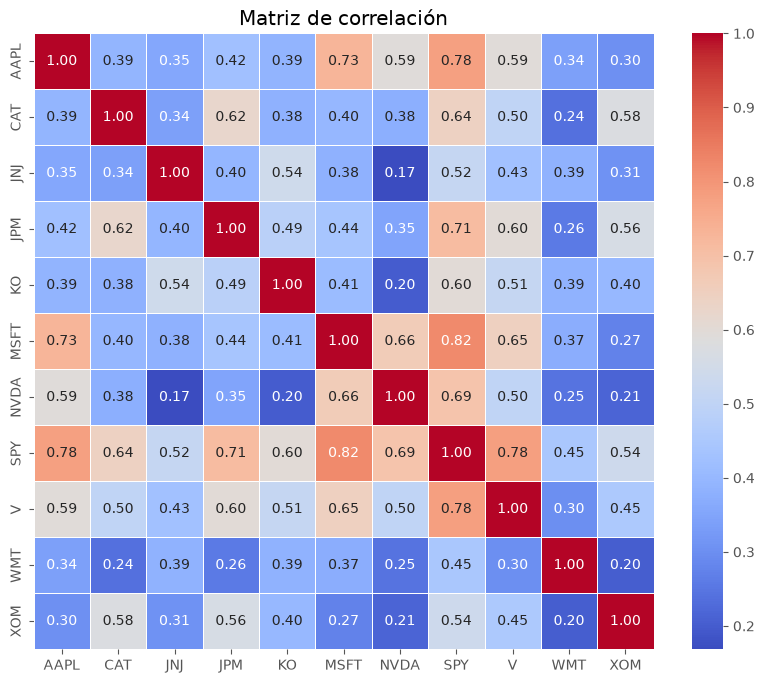

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de correlación")
plt.show()

## Distribución de los rendimientos diarios

Los histogramas muestran la distribución de los rendimientos diarios de cada activo.

Se observa que:

- La mayoría de los rendimientos se concentran alrededor de cero, indicando que los movimientos diarios suelen ser pequeños.

- Las distribuciones presentan colas relativamente largas, evidenciando la existencia de eventos extremos que ocurren con menor frecuencia.

- **NVIDIA** presenta una distribución considerablemente más dispersa, consistente con su mayor volatilidad.

- Activos como **JNJ**, **KO** y **SPY** muestran distribuciones más concentradas, reflejando un comportamiento históricamente más estable.

En conjunto, estas distribuciones muestran que los rendimientos financieros no siguen perfectamente una distribución normal, aspecto que debe considerarse al construir modelos de riesgo.

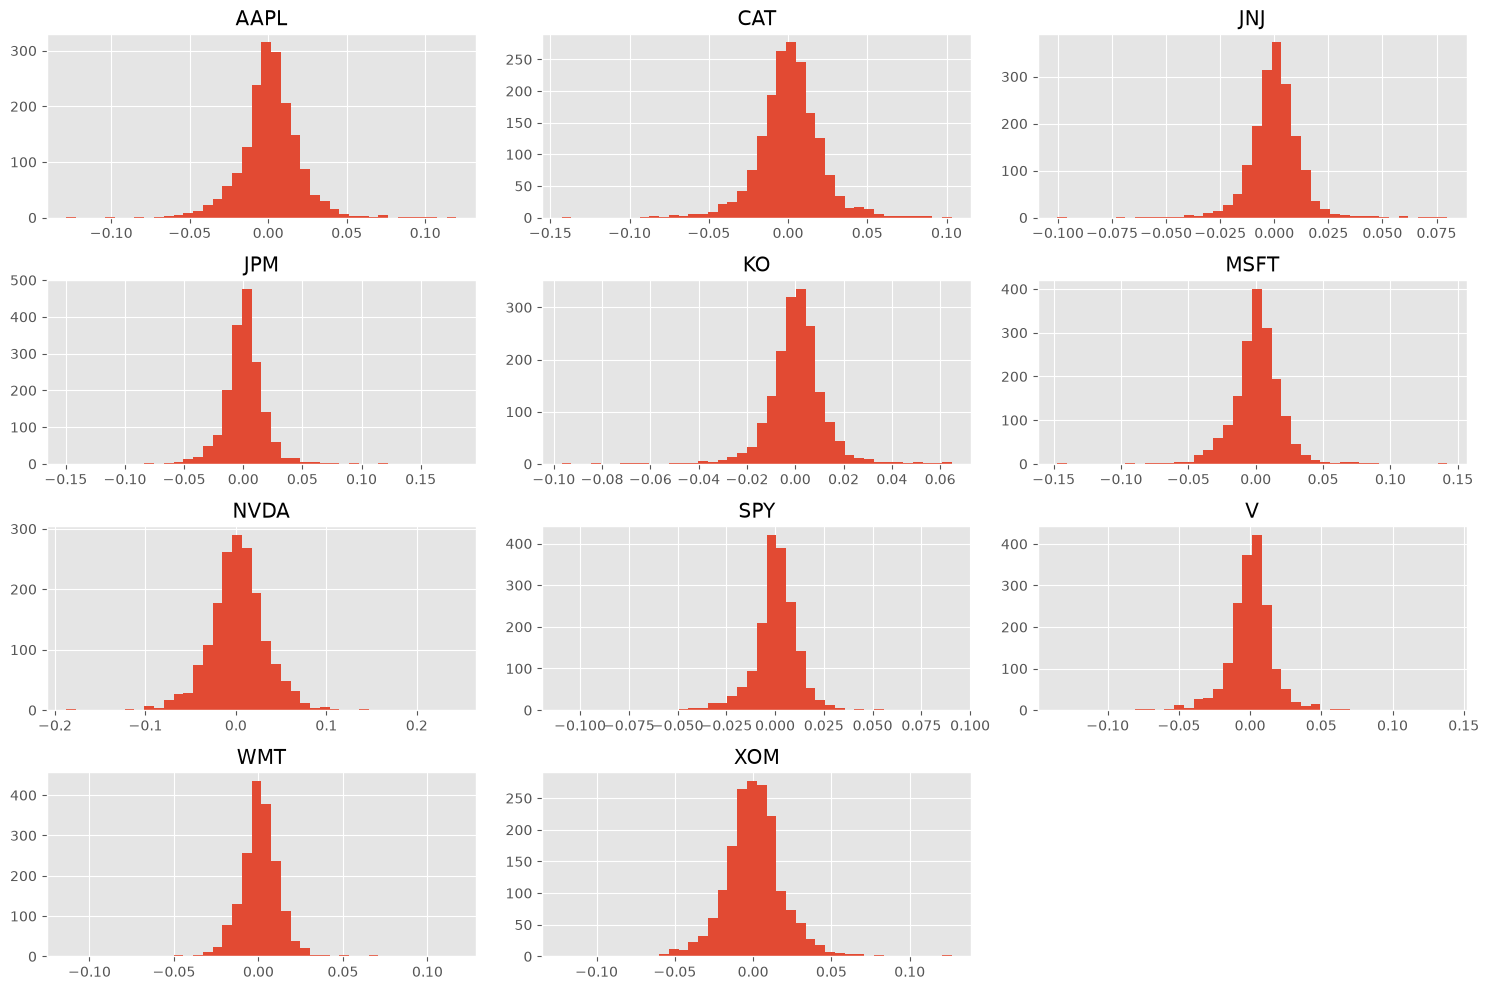

In [11]:
returns.hist(
    figsize=(15,10),
    bins=40
)

plt.tight_layout()
plt.show()

## Distribución mediante diagramas de caja

Los diagramas de caja permiten visualizar la dispersión de los rendimientos, su mediana y la presencia de valores atípicos.

Los principales hallazgos son:

- Todos los activos presentan valores atípicos tanto positivos como negativos, lo cual es habitual en series financieras.

- **NVIDIA** exhibe la mayor dispersión entre los cuartiles y la mayor cantidad de observaciones extremas, confirmando su elevado nivel de riesgo.

- **SPY**, **KO**, **JNJ** y **WMT** muestran cajas más estrechas, indicando una menor variabilidad diaria.

- La mediana de los rendimientos diarios se encuentra cercana a cero para todos los activos, comportamiento característico de los mercados financieros.

Estos resultados complementan el análisis de volatilidad y refuerzan la importancia de la diversificación para controlar el riesgo del portafolio.

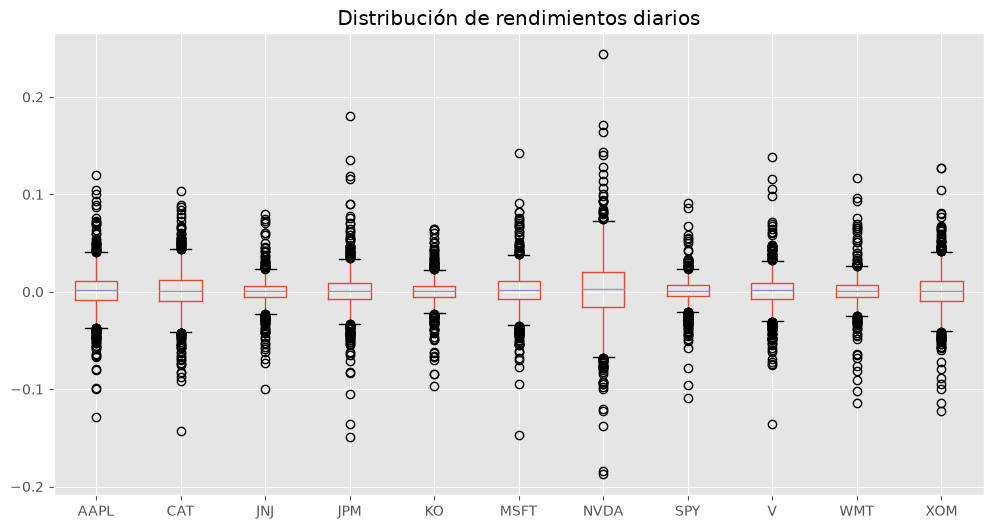

In [18]:
plt.figure(figsize=(12,6))

returns.boxplot()

plt.title("Distribución de rendimientos diarios")
plt.show()